# imports

In [1]:
# imports

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn

pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [2]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')
#imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [3]:
path = './data/'
csv_path = path + 'to_input_openfoodfacts.csv'
#csv_path = path + 'en.openfoodfacts.org.products.csv'
sm_df = pd.read_csv(csv_path, low_memory=False)

# Dataframe info

## functions

In [4]:
def get_df_columns_na(df):
    nan_values = df.isnull().sum()
    nan_percent = nan_values /df.shape[0]*100
    nan_info = pd.concat([nan_values,nan_percent],axis=1)
    nan_info.columns = ['count', 'null_percent']
    nan_info = nan_info.sort_values(by='null_percent',ascending=True)
    return nan_info

In [5]:
def plot_df_xy(df, x_val, y_val, height_val = 20, width_val = 13):
    sns.catplot(data=df, x= x_val, y= y_val, kind="bar", height=height_val, aspect=width_val/height_val)
    sns.set(rc={'figure.figsize':(width_val,height_val)})
    plt.xticks(rotation=70)
    plt.tight_layout()

In [6]:
def show_nulls(df, display=False):
    df_nulls = get_df_columns_na(df).sort_values(by='null_percent',ascending=False)
    print(df_nulls)
    if display == True:
        plot_df_xy(df_nulls.reset_index(), 'null_percent', 'index', 7)

In [7]:
def boxplot_nums_old(df, num_cols, energy_cols, scores_cols):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    fig, ax  = plt.subplots(1,3, gridspec_kw={'width_ratios': [8, 1, 1]})
    sns.boxplot(data=df[num_cols], ax=ax[0])
    sns.boxplot(data=df[energy_cols], ax=ax[1])
    sns.boxplot(data=df[scores_cols], ax=ax[2])
    ax[0].set_xticklabels(ax[0].get_xticklabels(),rotation=55)
    ax[1].set_xticklabels(ax[1].get_xticklabels(),rotation=55)
    ax[2].set_xticklabels(ax[2].get_xticklabels(),rotation=55)
    plt.show()

In [8]:
def boxplot_nums(df, cols_lists):
    sns.set(rc={'figure.figsize':(11.7,8.27)})
    
    col_lists_len = len(cols_lists)
    all_lists_len = []
    iter = 0
    for i in cols_lists:
        all_lists_len.append(len(i))
    
    fig, ax  = plt.subplots(1,col_lists_len, gridspec_kw={'width_ratios': all_lists_len})
    
    for i in cols_lists:
        sns.boxplot(data=df[i], ax=ax[iter])
        ax[iter].set_xticklabels(ax[iter].get_xticklabels(),rotation=55)
        iter+=1
    
    plt.show()

## General distribution / NaNs 

In [9]:
sm_df.shape

(46254, 15)

In [10]:
sm_df.head()

,code,nutrition_grade_fr,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,product_name,fiber_100g,fat_100g,carbohydrates_100g,pnns_groups_2,pnns_groups_1
0,10187319,d,14.0,0.6,1753.0,0.0100,0.003937,87.7,0.8,Mini Confettis,0.9,NaN,NaN,NaN,NaN
1,10207260,d,14.0,9.5,2406.0,0.0030,0.001181,50.3,2.9,Praliné Amande Et Noisette,3.9,NaN,NaN,NaN,NaN
2,40608754,e,13.0,0.0,177.0,0.0254,0.010000,10.4,0.0,"Pepsi, Nouveau goût !",0.0,0.0,10.4,Sweetened beverages,Beverages
3,69161025,d,15.0,7.5,1079.0,0.8000,0.314961,1.0,11.0,Tarte Poireaux Et Lardons,1.4,NaN,NaN,NaN,NaN
4,87177756,e,13.0,0.0,177.0,0.1000,0.039370,10.4,0.0,7Up,NaN,0.0,10.4,Sweetened beverages,Beverages


In [11]:
sm_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46254 entries, 0 to 46253
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   code                     46254 non-null  int64  
 1   nutrition_grade_fr       46254 non-null  object 
 2   nutrition-score-fr_100g  36796 non-null  float64
 3   proteins_100g            46187 non-null  float64
 4   energy_100g              46015 non-null  float64
 5   salt_100g                46186 non-null  float64
 6   sodium_100g              46187 non-null  float64
 7   sugars_100g              46184 non-null  float64
 8   saturated-fat_100g       46186 non-null  float64
 9   product_name             46254 non-null  object 
 10  fiber_100g               34517 non-null  float64
 11  fat_100g                 29410 non-null  float64
 12  carbohydrates_100g       29364 non-null  float64
 13  pnns_groups_2            27834 non-null  object 
 14  pnns_groups_1         

In [12]:
sm_df.describe()

,code,nutrition-score-fr_100g,proteins_100g,energy_100g,salt_100g,sodium_100g,sugars_100g,saturated-fat_100g,fiber_100g,fat_100g,carbohydrates_100g
count,4.625400e+04,36796.000000,46187.000000,46015.000000,46186.000000,46187.000000,46184.000000,46186.000000,34517.000000,29410.000000,29364.000000
mean,3.819760e+12,9.375068,8.002255,902.814028,1.030939,0.406938,8.410142,4.265709,2.082982,9.407097,16.340414
std,4.428525e+12,7.276457,8.175554,666.120119,2.220297,0.903142,14.188582,7.076040,4.110923,12.654028,20.163020
min,1.756000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.248830e+12,3.000000,1.500000,345.500000,0.080000,0.031496,0.800000,0.200000,0.000000,1.000000,2.500000
50%,3.329770e+12,9.000000,5.800000,751.000000,0.650000,0.255906,2.900000,1.400000,1.000000,4.200000,9.400000
75%,3.608581e+12,15.000000,12.000000,1403.000000,1.300000,0.511811,10.000000,5.000000,2.600000,12.900000,20.400000
max,3.661112e+14,36.000000,90.000000,3761.000000,68.200000,49.212598,100.000000,100.000000,100.000000,92.000000,100.000000


In [13]:
sm_df.columns.to_list()

['code',
 'nutrition_grade_fr',
 'nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'salt_100g',
 'sodium_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'product_name',
 'fiber_100g',
 'fat_100g',
 'carbohydrates_100g',
 'pnns_groups_2',
 'pnns_groups_1']

In [14]:
sm_num_cols = ['fat_100g', 'saturated-fat_100g',
               'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 
               'salt_100g','sodium_100g',
               'fiber_100g']
energy_cols = ['energy_100g']
scores_cols = ['nutrition-score-fr_100g'
               #'ecoscore_grade'
              ]

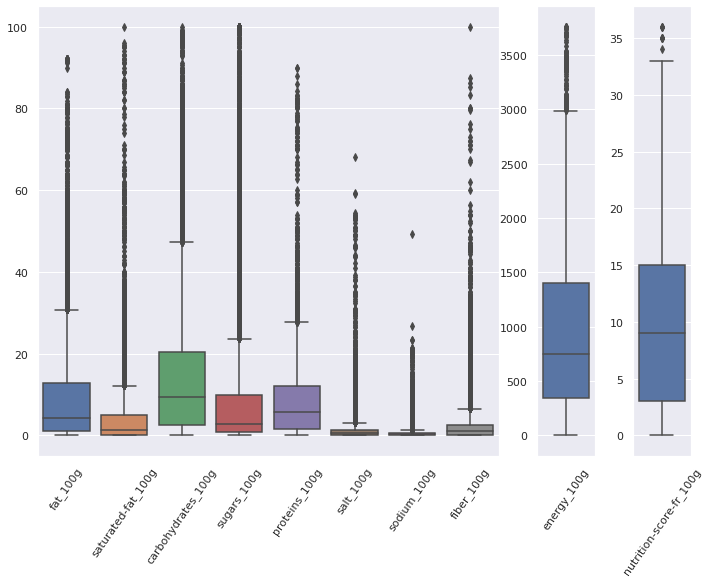

In [15]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [16]:
## initial (2 282 517, 186)

sm_df.shape

(46254, 15)

In [17]:
#sm_df.isna().sum()

In [18]:
show_nulls(sm_df)

                         count  null_percent
pnns_groups_1            18508     40.013837
pnns_groups_2            18420     39.823583
carbohydrates_100g       16890     36.515761
fat_100g                 16844     36.416310
fiber_100g               11737     25.375103
nutrition-score-fr_100g   9458     20.447961
energy_100g                239      0.516712
sugars_100g                 70      0.151338
salt_100g                   68      0.147014
saturated-fat_100g          68      0.147014
proteins_100g               67      0.144852
sodium_100g                 67      0.144852
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000


## Categories / "unknown"

In [19]:
main_cats = sm_df['pnns_groups_1'].unique()
main_cats

array([nan, 'Beverages', 'Fruits and vegetables', 'Salty snacks',
       'Composite foods', 'Fat and sauces', 'Sugary snacks',
       'Milk and dairy products', 'Cereals and potatoes',
       'Fish Meat Eggs'], dtype=object)

In [20]:
sm_df['pnns_groups_1'].value_counts()

Composite foods            4763
Milk and dairy products    4725
Fish Meat Eggs             4444
Beverages                  3789
Cereals and potatoes       3465
Fruits and vegetables      2741
Fat and sauces             2007
Sugary snacks              1231
Salty snacks                581
Name: pnns_groups_1, dtype: int64

In [21]:
all_cats = sm_df['pnns_groups_1'].unique().tolist()
all_cats

[nan,
 'Beverages',
 'Fruits and vegetables',
 'Salty snacks',
 'Composite foods',
 'Fat and sauces',
 'Sugary snacks',
 'Milk and dairy products',
 'Cereals and potatoes',
 'Fish Meat Eggs']

In [22]:
all_cols = sm_df.columns
all_cols

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [23]:
main_cats = ['fat_100g', 'salt_100g']
complementary_cats = ['saturated-fat_100g','sodium_100g']

In [24]:
final_cats = [c for c in all_cols if c not in main_cats+complementary_cats]
final_cats

['code',
 'nutrition_grade_fr',
 'nutrition-score-fr_100g',
 'proteins_100g',
 'energy_100g',
 'sugars_100g',
 'product_name',
 'fiber_100g',
 'carbohydrates_100g',
 'pnns_groups_2',
 'pnns_groups_1']

In [25]:
all_cols

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [26]:
num_cols = sm_df.columns[sm_df.dtypes == 'float64']
num_cols

Index(['nutrition-score-fr_100g', 'proteins_100g', 'energy_100g', 'salt_100g',
       'sodium_100g', 'sugars_100g', 'saturated-fat_100g', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g'],
      dtype='object')

# Inputing

## categories : most frequent

In [27]:
sm_df['pnns_groups_1'].value_counts()

Composite foods            4763
Milk and dairy products    4725
Fish Meat Eggs             4444
Beverages                  3789
Cereals and potatoes       3465
Fruits and vegetables      2741
Fat and sauces             2007
Sugary snacks              1231
Salty snacks                581
Name: pnns_groups_1, dtype: int64

In [28]:
sm_df.shape

(46254, 15)

In [29]:
## categorical pnn1 

## inputing valeur vides avec valeur plus fréQUENTE / SIMPLE IMPUTER _ strategy most _frequent
# SimpleImputer(strategy="most_frequent")

In [30]:
from sklearn.impute import SimpleImputer

In [31]:
imp_fre = SimpleImputer(missing_values=np.nan, strategy= 'most_frequent')

In [32]:
imp_pnns = imp_fre.fit_transform(sm_df[['pnns_groups_1', 'pnns_groups_2']])
imp_pnns

array([['Composite foods', 'One-dish meals'],
       ['Composite foods', 'One-dish meals'],
       ['Beverages', 'Sweetened beverages'],
       ...,
       ['Composite foods', 'One-dish meals'],
       ['Composite foods', 'One-dish meals'],
       ['Beverages', 'Non-sugared beverages']], dtype=object)

In [33]:
sm_df[['pnns_groups_1', 'pnns_groups_2']] = imp_pnns

In [34]:
show_nulls(sm_df)

                         count  null_percent
carbohydrates_100g       16890     36.515761
fat_100g                 16844     36.416310
fiber_100g               11737     25.375103
nutrition-score-fr_100g   9458     20.447961
energy_100g                239      0.516712
sugars_100g                 70      0.151338
salt_100g                   68      0.147014
saturated-fat_100g          68      0.147014
proteins_100g               67      0.144852
sodium_100g                 67      0.144852
code                         0      0.000000
nutrition_grade_fr           0      0.000000
product_name                 0      0.000000
pnns_groups_2                0      0.000000
pnns_groups_1                0      0.000000


In [35]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].head()

,pnns_groups_1,pnns_groups_2
0,Composite foods,One-dish meals
1,Composite foods,One-dish meals
2,Beverages,Sweetened beverages
3,Composite foods,One-dish meals
4,Beverages,Sweetened beverages


In [36]:
sm_df[['pnns_groups_1', 'pnns_groups_2']].value_counts()

pnns_groups_1            pnns_groups_2                   
Composite foods          One-dish meals                      22299
Cereals and potatoes     Cereals                              2219
Fish Meat Eggs           Processed meat                       2080
Milk and dairy products  Cheese                               2056
Fat and sauces           Dressings and sauces                 1744
Milk and dairy products  Milk and yogurt                      1626
Fish Meat Eggs           Fish and seafood                     1494
Beverages                Fruit juices                         1245
                         Non-sugared beverages                1122
Fruits and vegetables    Vegetables                           1082
Beverages                Sweetened beverages                  1019
Fruits and vegetables    Fruits                                827
Fish Meat Eggs           Meat                                  770
Cereals and potatoes     Bread                                 706
Milk

## numerical values

In [37]:
### appliquer imputer différentes strategies (check distribution) avec un groupby categories
### iterative imputer / estimation du choix d'imputer selon la distribution (mean/median/most frequent...)


In [38]:
# Use mean imputation if variables are normally distributed and median imputation otherwise. 
# Mean and median imputation may distort 
# the distribution of the original variables if there is a high percentage of missing data.

In [39]:
sm_num_cols

['fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g',
 'fiber_100g']

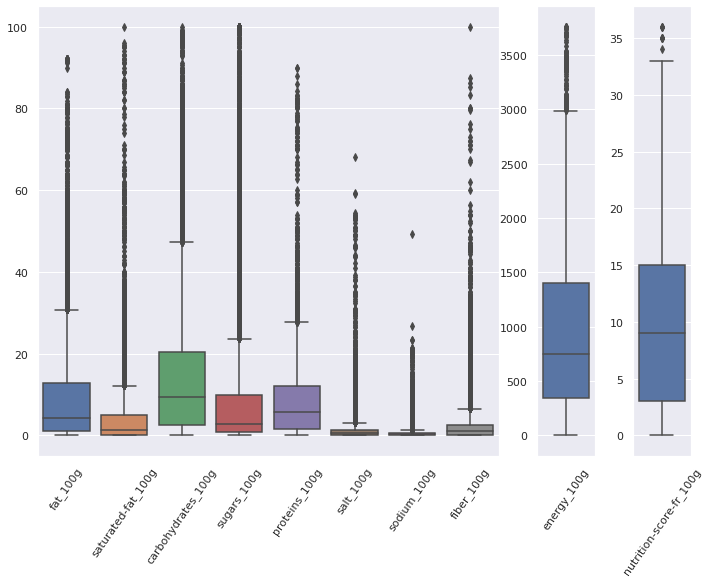

In [40]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [41]:
energy_cols

['energy_100g']

### sm_num_cols : fat / salt => median input

In [42]:
#imp_med = SimpleImputer(missing_values=np.nan, strategy='median')

###sm_df[all_num_cols] = imp_med.fit_transform(sm_df[all_num_cols])

In [43]:
# sm_df[[c for c in df.columns if c in main_cats]].head()

In [44]:
sm_df.filter(sm_num_cols).head()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,fiber_100g
0,NaN,0.8,NaN,87.7,0.6,0.0100,0.003937,0.9
1,NaN,2.9,NaN,50.3,9.5,0.0030,0.001181,3.9
2,0.0,0.0,10.4,10.4,0.0,0.0254,0.010000,0.0
3,NaN,11.0,NaN,1.0,7.5,0.8000,0.314961,1.4
4,0.0,0.0,10.4,10.4,0.0,0.1000,0.039370,NaN


In [45]:
sm_df_groupby = sm_df.groupby(by='pnns_groups_1')

In [46]:
sm_df.columns

Index(['code', 'nutrition_grade_fr', 'nutrition-score-fr_100g',
       'proteins_100g', 'energy_100g', 'salt_100g', 'sodium_100g',
       'sugars_100g', 'saturated-fat_100g', 'product_name', 'fiber_100g',
       'fat_100g', 'carbohydrates_100g', 'pnns_groups_2', 'pnns_groups_1'],
      dtype='object')

In [47]:
sm_df_groupby[sm_num_cols].median()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,fiber_100g
pnns_groups_1,,,,,,,,
Beverages,0.0,0.00,9.70,9.0,0.3,0.0100,0.003937,0.100
Cereals and potatoes,2.0,0.40,59.00,2.5,9.8,0.2000,0.078740,3.500
Composite foods,6.7,1.90,12.41,2.9,6.2,0.7500,0.295276,1.000
Fat and sauces,12.0,2.00,6.10,3.6,1.4,1.5000,0.590551,1.000
Fish Meat Eggs,10.6,2.60,0.90,0.6,19.5,1.8000,0.708661,0.001
Fruits and vegetables,0.4,0.10,6.07,3.1,1.1,0.2159,0.085000,2.000
Milk and dairy products,9.7,6.50,4.80,4.6,4.5,0.1524,0.060000,0.000
Salty snacks,26.3,2.90,49.50,2.0,6.4,1.3000,0.511811,4.000
Sugary snacks,2.1,1.35,46.05,19.1,3.6,0.1300,0.051181,1.300


In [48]:
sm_df_groupby[sm_num_cols].count()

,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,fiber_100g
pnns_groups_1,,,,,,,,
Beverages,3119,3771,3131,3771,3771,3771,3771,2520
Cereals and potatoes,3208,3463,3220,3463,3463,3463,3463,2870
Composite foods,8644,23241,8625,23239,23241,23240,23241,20264
Fat and sauces,1816,2004,1815,2004,2004,2004,2004,1136
Fish Meat Eggs,4241,4441,4231,4441,4441,4441,4441,1898
Fruits and vegetables,2547,2739,2555,2739,2739,2739,2739,2346
Milk and dairy products,4487,4720,4439,4719,4720,4720,4720,2249
Salty snacks,503,579,502,580,580,580,580,316
Sugary snacks,845,1228,846,1228,1228,1228,1228,918


In [49]:
# https://pandas.pydata.org/docs/user_guide/groupby.html

sm_df[sm_num_cols] = sm_df_groupby[sm_num_cols].transform(lambda x: x.fillna(x.median()))

In [50]:
sm_df.isna().sum()

code                          0
nutrition_grade_fr            0
nutrition-score-fr_100g    9458
proteins_100g                 0
energy_100g                 239
salt_100g                     0
sodium_100g                   0
sugars_100g                   0
saturated-fat_100g            0
product_name                  0
fiber_100g                    0
fat_100g                      0
carbohydrates_100g            0
pnns_groups_2                 0
pnns_groups_1                 0
dtype: int64

In [51]:
show_nulls(sm_df)

                         count  null_percent
nutrition-score-fr_100g   9458     20.447961
energy_100g                239      0.516712
code                         0      0.000000
nutrition_grade_fr           0      0.000000
proteins_100g                0      0.000000
salt_100g                    0      0.000000
sodium_100g                  0      0.000000
sugars_100g                  0      0.000000
saturated-fat_100g           0      0.000000
product_name                 0      0.000000
fiber_100g                   0      0.000000
fat_100g                     0      0.000000
carbohydrates_100g           0      0.000000
pnns_groups_2                0      0.000000
pnns_groups_1                0      0.000000


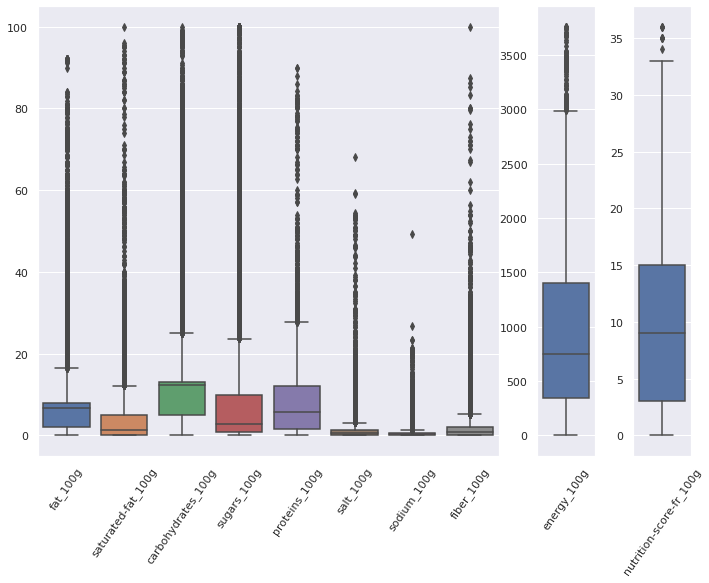

In [52]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

In [53]:
#sm_df_gr_transf = sm_df_groupby[main_cats].transform(lambda x: x.fillna(x.mean()))
#sm_df_gr_transf

In [54]:
#grouped.transform(lambda x: x.fillna(inplace=False))

## energy_100 / nutrition_score: mean inputing

In [55]:
sm_df_groupby[energy_cols+scores_cols].mean()

,energy_100g,nutrition-score-fr_100g
pnns_groups_1,,
Beverages,188.797017,7.639745
Cereals and potatoes,1223.079691,4.076985
Composite foods,1007.189627,9.649005
Fat and sauces,1137.965872,11.537906
Fish Meat Eggs,852.493770,10.738947
Fruits and vegetables,274.016969,1.988728
Milk and dairy products,836.730676,9.211802
Salty snacks,1894.692573,11.606947
Sugary snacks,1217.795020,11.039496


In [56]:
sm_df[energy_cols+scores_cols] = sm_df_groupby[energy_cols+scores_cols].transform(lambda x: x.fillna(x.mean()))

# Check nulls

In [57]:
sm_df.shape

(46254, 15)

In [58]:
show_nulls(sm_df)

                         count  null_percent
code                         0           0.0
nutrition_grade_fr           0           0.0
nutrition-score-fr_100g      0           0.0
proteins_100g                0           0.0
energy_100g                  0           0.0
salt_100g                    0           0.0
sodium_100g                  0           0.0
sugars_100g                  0           0.0
saturated-fat_100g           0           0.0
product_name                 0           0.0
fiber_100g                   0           0.0
fat_100g                     0           0.0
carbohydrates_100g           0           0.0
pnns_groups_2                0           0.0
pnns_groups_1                0           0.0


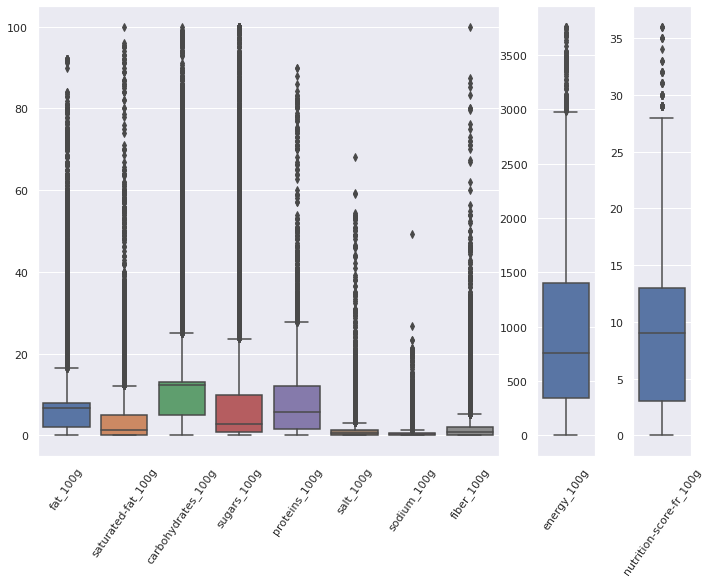

In [59]:
boxplot_nums(sm_df, [sm_num_cols, energy_cols, scores_cols])

# export to csv

In [60]:
#sm_df.reset_index()

sm_df.to_csv(path + 'clean_openfoodfacts_3.csv', index=False)
print('export finished !')

export finished !


In [61]:
ls -lh ./data

total 8,9G
-rw-r--r-- 1 mijka mijka 6,0M  6 mars  09:25 clean_openfoodfacts_3.csv
-rw-r--r-- 1 mijka mijka 8,1G  1 déc.  17:49 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,2M  6 mars  09:25 to_input_openfoodfacts.csv
